# Comparing Unsupervised Learning Algorithms
This notebook compares different unsupervised learning algorithms using the `load_wine` dataset from scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Wine dataset
data = load_wine()
X = data.data
df = pd.DataFrame(X, columns=data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


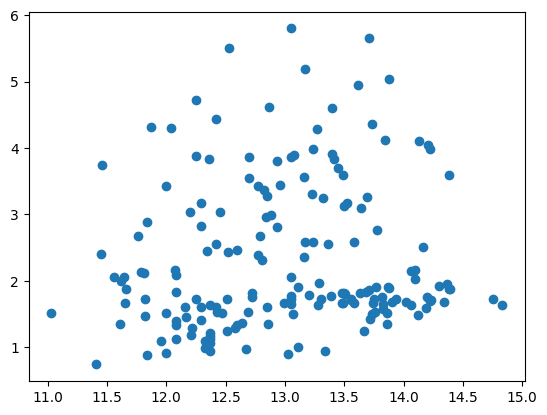

In [5]:
# Standardizing the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.scatter(X[:, 0], X[:, 1])

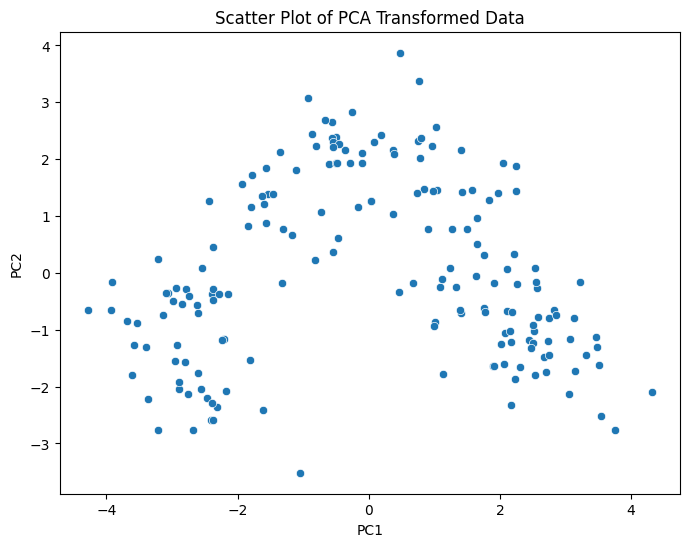

In [6]:
# Perform PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'])
plt.title('Scatter Plot of PCA Transformed Data')
plt.show()

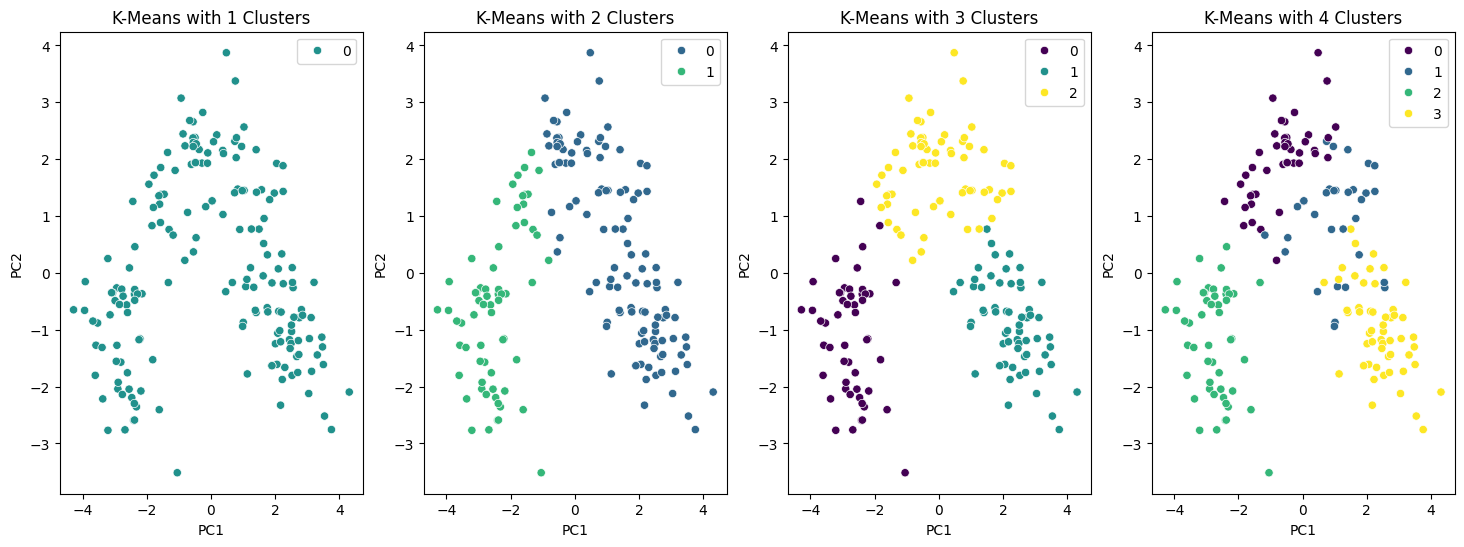

In [9]:
# Apply KMeans clustering with different cluster numbers
fig, axes = plt.subplots(1, 4, figsize=(18,6))
for i, k in enumerate([1,2,3,4]):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df_pca[f'Cluster_{k}'] = clusters
    sns.scatterplot(ax=axes[i], x=df_pca['PC1'], y=df_pca['PC2'], hue=clusters, palette='viridis')
    axes[i].set_title(f'K-Means with {k} Clusters')
plt.show()

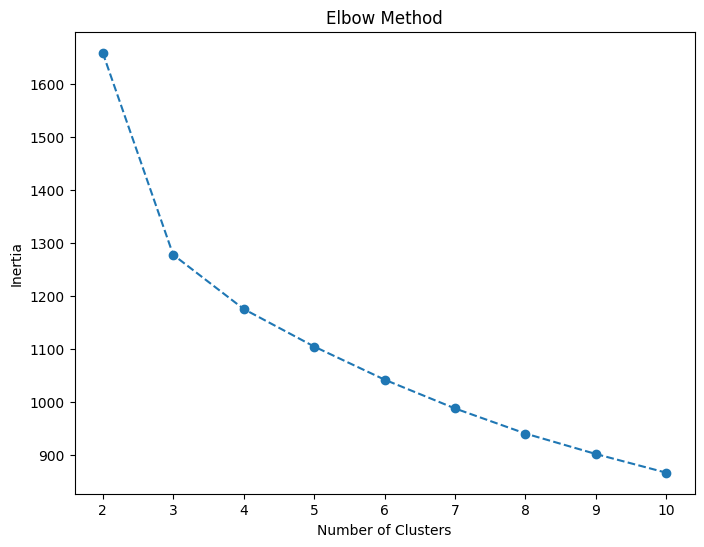

In [10]:
# Using the Elbow method to find the optimal number of clusters
inertia = []
silhouette_scores = {}
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores[k] = silhouette_score(X_scaled, clusters)

# Plot Elbow Method
plt.figure(figsize=(8,6))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Best Number of Clusters: 3


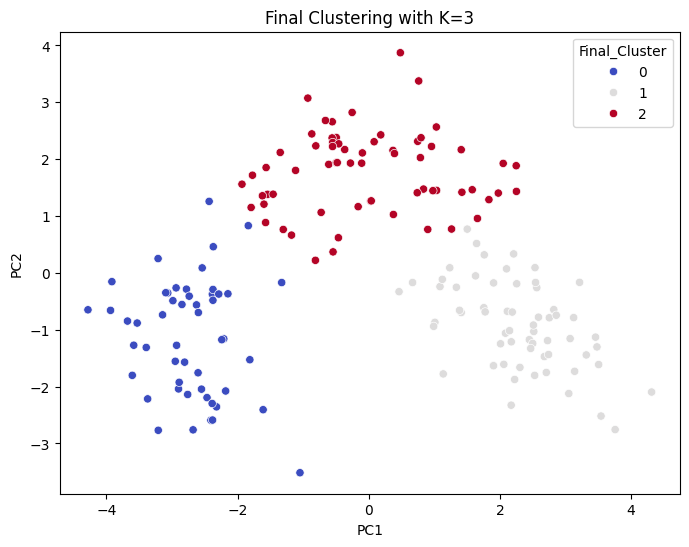

In [11]:
# Selecting the best cluster count using silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'Best Number of Clusters: {best_k}')

# Final KMeans Clustering with best K
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_pca['Final_Cluster'] = clusters

# Final cluster visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['Final_Cluster'], palette='coolwarm')
plt.title(f'Final Clustering with K={best_k}')
plt.show()